In [1]:
import os
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    mean_absolute_error,
    mean_squared_error,
    precision_score,
    r2_score,
    recall_score,
)
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor, plot_tree

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

FIG_DIR = os.path.join("figures")
os.makedirs(FIG_DIR, exist_ok=True)

DATA_PATH = os.path.join("..", "data", "processed", "cleaned_dataset.csv")
df = pd.read_csv(DATA_PATH)
print("Processed dataset loaded successfully.")
print(f"Dataset Shape: {df.shape[0]} rows, {df.shape[1]} columns")

Processed dataset loaded successfully.
Dataset Shape: 7308 rows, 11 columns


In [2]:
# --- DEFINING PREDICTOR SETS (X) ---
# Rainfall_mm excluded from all X sets (temporary y_reg)

# set 1: for linear Models (no Elevation_m; drop 1 dummy to prevent dummy variable trap)
linear_features = [
    "WaterLevel_m",
    "SoilMoisture_pct",
    "Location_Marikina",
    "Location_Pasig",
    "Location_Quezon City",  # Manila as reference
]
X_linear = df[linear_features].copy()

# set 2: For CART Tree Models (with Elevation_m and all 4 city dummies)
cart_features = [
    "WaterLevel_m",
    "SoilMoisture_pct",
    "Elevation_m",
    "Location_Manila",
    "Location_Marikina",
    "Location_Pasig",
    "Location_Quezon City",
]
X_cart = df[cart_features].copy()

# --- DEFINING TARGETS (y) ---
y_reg = df["Rainfall_mm"].copy() # NOTE: placeholder regression target (continuous)
y_clf = df["FloodOccurrence"].copy() # practice clf Target (binary) - for sample code only

# --- TRAIN-TEST SPLITS (80/20) ---
# regression Splits
X_train_lin_reg, X_test_lin_reg, y_train_reg, y_test_reg = train_test_split(
    X_linear, y_reg, test_size=0.20, random_state=42
)
X_train_cart_reg, X_test_cart_reg, _, _ = train_test_split(
    X_cart, y_reg, test_size=0.20, random_state=42
)

# classification splits
X_train_lin_clf, X_test_lin_clf, y_train_clf, y_test_clf = train_test_split(
    X_linear, y_clf, test_size=0.20, random_state=42, stratify=y_clf
) # stratified for balance
X_train_cart_clf, X_test_cart_clf, _, _ = train_test_split(
    X_cart, y_clf, test_size=0.20, random_state=42, stratify=y_clf
)

print(f"Linear Feature Set ({len(linear_features)}): {linear_features}")
print(f"CART Feature Set ({len(cart_features)}): {cart_features}")
print(f"Training samples: {X_train_lin_reg.shape[0]} | Testing samples: {X_test_lin_reg.shape[0]}")

Linear Feature Set (5): ['WaterLevel_m', 'SoilMoisture_pct', 'Location_Marikina', 'Location_Pasig', 'Location_Quezon City']
CART Feature Set (7): ['WaterLevel_m', 'SoilMoisture_pct', 'Elevation_m', 'Location_Manila', 'Location_Marikina', 'Location_Pasig', 'Location_Quezon City']
Training samples: 5846 | Testing samples: 1462


In [3]:
# --- MULTIPLE LINEAR REGRESSION BASELINE ---
# predictor set: WITHOUT Elevation_m, 1 city dummy dropped (ref: Manila)
# target: Rainfall_mm (temporary placeholder)

lin_reg_model = LinearRegression()
lin_reg_model.fit(X_train_lin_reg, y_train_reg)

y_pred_lin_reg = lin_reg_model.predict(X_test_lin_reg)

# regression evaluation metrics
mae_lin = mean_absolute_error(y_test_reg, y_pred_lin_reg)
rmse_lin = np.sqrt(mean_squared_error(y_test_reg, y_pred_lin_reg))
r2_lin = r2_score(y_test_reg, y_pred_lin_reg)

print("---BASELINE: MULTIPLE LINEAR REGRESSION RESULTS---")
print(f"Mean Absolute Error (MAE):     {mae_lin:.4f} mm")
print(f"Root Mean Squared Error (RMSE): {rmse_lin:.4f} mm")
print(f"R-squared (R2 Score):          {r2_lin:.4f}")

# coefficients and intercept
coef_df = pd.DataFrame({
    'Feature': linear_features,
    'Coefficient': lin_reg_model.coef_
}).sort_values(by='Coefficient', ascending=False)

print(f"Intercept: {lin_reg_model.intercept_:.4f}")
print("\n--- Model Coefficients ---")
display(coef_df)

---BASELINE: MULTIPLE LINEAR REGRESSION RESULTS---
Mean Absolute Error (MAE):     3.8469 mm
Root Mean Squared Error (RMSE): 4.9179 mm
R-squared (R2 Score):          0.4844
Intercept: -2.2727

--- Model Coefficients ---


,Feature,Coefficient
0,WaterLevel_m,3.592730
1,SoilMoisture_pct,0.503336
4,Location_Quezon City,0.355038
3,Location_Pasig,0.238901
2,Location_Marikina,-0.049311


---BASELINE: LOGISTIC REGRESSION (PRACTICE RUN)---
Accuracy:  0.9378
Precision: 0.2222
Recall:    1.0000 (Priority Metric for Flood Risk)
F1-Score:  0.3636

--- Detailed Classification Report ---
              precision    recall  f1-score   support

No Flood (0)       1.00      0.94      0.97      1436
   Flood (1)       0.22      1.00      0.36        26

    accuracy                           0.94      1462
   macro avg       0.61      0.97      0.67      1462
weighted avg       0.99      0.94      0.96      1462



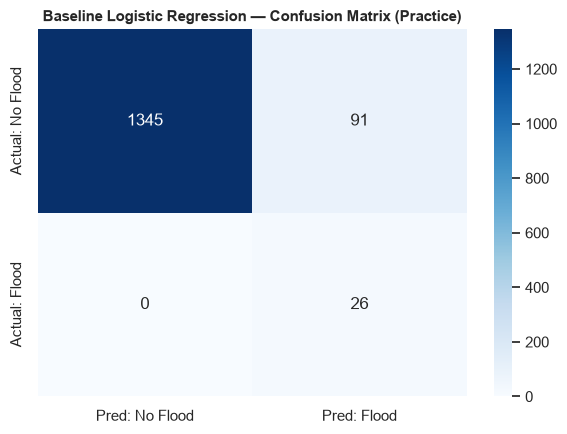

In [4]:
# ---LOGISTIC REGRESSION CLASSIFICATION BASELINE (DRY RUN)---
# NOTE: This is practice pipeline code using FloodOccurrence (0/1).
# Formal thesis modeling will revisit this when RiskLevel (3 classes)
# is derived from FloodDepth_m using official MGB thresholds.
# Predictor set: WITHOUT Elevation_m, 1 dummy dropped (ref: Manila)

log_reg_model = LogisticRegression(class_weight="balanced", max_iter=1000, random_state=42)
log_reg_model.fit(X_train_lin_clf, y_train_clf)

y_pred_log_reg = log_reg_model.predict(X_test_lin_clf)

acc_log = accuracy_score(y_test_clf, y_pred_log_reg)
prec_log = precision_score(y_test_clf, y_pred_log_reg, zero_division=0)
rec_log = recall_score(y_test_clf, y_pred_log_reg, zero_division=0)
f1_log = f1_score(y_test_clf, y_pred_log_reg, zero_division=0)

print("---BASELINE: LOGISTIC REGRESSION (PRACTICE RUN)---")
print(f"Accuracy:  {acc_log:.4f}")
print(f"Precision: {prec_log:.4f}")
print(f"Recall:    {rec_log:.4f} (Priority Metric for Flood Risk)")
print(f"F1-Score:  {f1_log:.4f}")

print("\n--- Detailed Classification Report ---")
print(classification_report(y_test_clf, y_pred_log_reg, target_names=["No Flood (0)", "Flood (1)"], zero_division=0))

cm_log = confusion_matrix(y_test_clf, y_pred_log_reg)
plt.figure(figsize=(6, 4.5))
sns.heatmap(cm_log, annot=True, fmt="d", cmap="Blues", 
            xticklabels=["Pred: No Flood", "Pred: Flood"], 
            yticklabels=["Actual: No Flood", "Actual: Flood"])
plt.title("Baseline Logistic Regression — Confusion Matrix (Practice)", fontsize=11, fontweight="bold")
plt.tight_layout()
plt.show()

In [5]:
# ---CART DECISION TREE REGRESSOR (PRIMARY MODEL)---
# Predictor set: WITH Elevation_m and all Location dummies included
# Hyperparameter: max_depth=3 (interpretable, prevents overfitting)
# Target: Rainfall_mm (temporary placeholder)

tree_reg_model = DecisionTreeRegressor(max_depth=3, min_samples_leaf=20, random_state=42)
tree_reg_model.fit(X_train_cart_reg, y_train_reg)

y_pred_tree_reg = tree_reg_model.predict(X_test_cart_reg)

mae_tree = mean_absolute_error(y_test_reg, y_pred_tree_reg)
rmse_tree = np.sqrt(mean_squared_error(y_test_reg, y_pred_tree_reg))
r2_tree = r2_score(y_test_reg, y_pred_tree_reg)

print("---PRIMARY MODEL: CART DECISION TREE REGRESSOR---")
print(f"Mean Absolute Error (MAE):     {mae_tree:.4f} mm")
print(f"Root Mean Squared Error (RMSE): {rmse_tree:.4f} mm")
print(f"R-squared (R2 Score):          {r2_tree:.4f}")

comparison_reg_df = pd.DataFrame({
    "Model": ["Multiple Linear Regression (Baseline)", "Decision Tree Regressor (CART Primary)"],
    "Predictor Set Used": ["Without Elevation (Collinearity Control)", "With Elevation (All Features)"],
    "MAE (mm)": [mae_lin, mae_tree],
    "RMSE (mm)": [rmse_lin, rmse_tree],
    "R² Score": [r2_lin, r2_tree]
})

print("\n--- Regression Model Comparison Summary ---")
display(comparison_reg_df.round(4))

---PRIMARY MODEL: CART DECISION TREE REGRESSOR---
Mean Absolute Error (MAE):     4.0344 mm
Root Mean Squared Error (RMSE): 5.2277 mm
R-squared (R2 Score):          0.4174

--- Regression Model Comparison Summary ---


,Model,Predictor Set Used,MAE (mm),RMSE (mm),R² Score
0,Multiple Linear Regression (Baseline),Without Elevation (Collinearity Control),3.8469,4.9179,0.4844
1,Decision Tree Regressor (CART Primary),With Elevation (All Features),4.0344,5.2277,0.4174


---PRIMARY: CART DECISION TREE CLASSIFIER (PRACTICE)---
Accuracy:  0.9200
Precision: 0.1727
Recall:    0.9231 (Priority Metric)
F1-Score:  0.2909

--- Classification Model Comparison Summary (Practice Target) ---


,Model,Predictor Set Used,Accuracy,Precision,Recall,F1-Score
0,Logistic Regression (Baseline),Without Elevation (Collinearity Control),0.9378,0.2222,1.0000,0.3636
1,Decision Tree Classifier (CART Primary),With Elevation (All Features),0.9200,0.1727,0.9231,0.2909


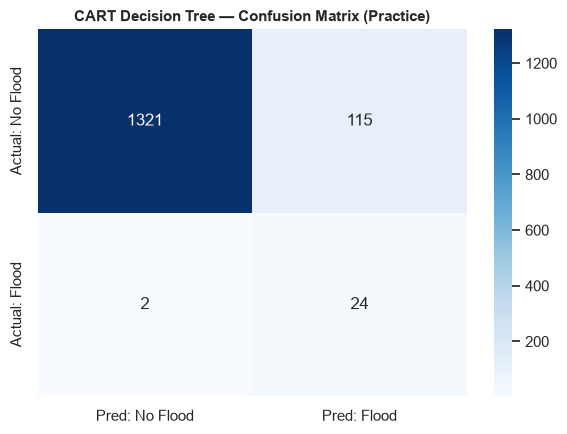

In [6]:
# ---CART DECISION TREE CLASSIFIER (PRACTICE PIPELINE)---
# NOTE: Testing the CART classification workflow on FloodOccurrence (0/1).
# Formal thesis modeling will revisit this when RiskLevel (Low/Mod/High)
# is derived using official MGB thresholds.
# Predictor set: WITH Elevation_m and all Location dummies

tree_clf_model = DecisionTreeClassifier(
    max_depth=3, class_weight="balanced", min_samples_leaf=20, random_state=42
)
tree_clf_model.fit(X_train_cart_clf, y_train_clf)

y_pred_tree_clf = tree_clf_model.predict(X_test_cart_clf)

acc_tree = accuracy_score(y_test_clf, y_pred_tree_clf)
prec_tree = precision_score(y_test_clf, y_pred_tree_clf, zero_division=0)
rec_tree = recall_score(y_test_clf, y_pred_tree_clf, zero_division=0)
f1_tree = f1_score(y_test_clf, y_pred_tree_clf, zero_division=0)

print("---PRIMARY: CART DECISION TREE CLASSIFIER (PRACTICE)---")
print(f"Accuracy:  {acc_tree:.4f}")
print(f"Precision: {prec_tree:.4f}")
print(f"Recall:    {rec_tree:.4f} (Priority Metric)")
print(f"F1-Score:  {f1_tree:.4f}")

comparison_clf_df = pd.DataFrame(
    {
        "Model": [
            "Logistic Regression (Baseline)",
            "Decision Tree Classifier (CART Primary)",
        ],
        "Predictor Set Used": [
            "Without Elevation (Collinearity Control)",
            "With Elevation (All Features)",
        ],
        "Accuracy": [acc_log, acc_tree],
        "Precision": [prec_log, prec_tree],
        "Recall": [rec_log, rec_tree],
        "F1-Score": [f1_log, f1_tree],
    }
)

print("\n--- Classification Model Comparison Summary (Practice Target) ---")
display(comparison_clf_df.round(4))

cm_tree = confusion_matrix(y_test_clf, y_pred_tree_clf)
plt.figure(figsize=(6, 4.5))
sns.heatmap(
    cm_tree,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Pred: No Flood", "Pred: Flood"],
    yticklabels=["Actual: No Flood", "Actual: Flood"],
)
plt.title(
    "CART Decision Tree — Confusion Matrix (Practice)",
    fontsize=11,
    fontweight="bold",
)
plt.tight_layout()
plt.show()

findfont: Failed to find font weight medium, now using 400.


Saved feature importance plot to: figures\cart_regressor_feature_importance.png


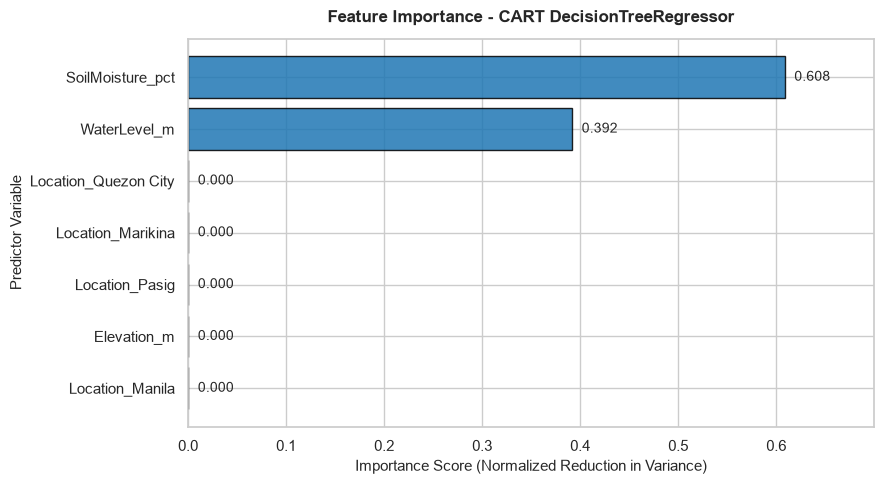


--- Feature Importance Table ---


,Feature,Importance
0,SoilMoisture_pct,0.60844
1,WaterLevel_m,0.39156
2,Location_Manila,0.00000
3,Location_Pasig,0.00000
4,Elevation_m,0.00000
5,Location_Quezon City,0.00000
6,Location_Marikina,0.00000


In [7]:
# ---FEATURE IMPORTANCE & EXPLAINABILITY - REGRESSOR TREE---
# Metric: MSE

importances = tree_reg_model.feature_importances_
feature_names = cart_features

fi_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=True)

# horizontal bar chart
plt.figure(figsize=(9, 5))
bars = plt.barh(fi_df['Feature'], fi_df['Importance'], color='#1f77b4', edgecolor='black', alpha=0.85)
plt.title("Feature Importance - CART DecisionTreeRegressor", fontsize=12, fontweight='bold', pad=12)
plt.xlabel("Importance Score (Normalized Reduction in Variance)", fontsize=11)
plt.ylabel("Predictor Variable", fontsize=11)
plt.xlim(0, max(fi_df['Importance']) * 1.15 if max(fi_df['Importance']) > 0 else 1)

for bar in bars:
    width = bar.get_width()
    plt.text(
        width + 0.01, 
        bar.get_y() + 
        bar.get_height()/2, 
        f"{width:.3f}", 
        va='center', 
        ha='left', 
        fontsize=10, 
        fontweight='medium'
    )

plt.tight_layout()

# notebooks/figures/
fi_export_path = os.path.join(FIG_DIR, "cart_regressor_feature_importance.png")
plt.savefig(fi_export_path, dpi=300, bbox_inches='tight')
print(f"Saved feature importance plot to: {fi_export_path}")
plt.show()

# table
print("\n--- Feature Importance Table ---")
display(fi_df.sort_values(by='Importance', ascending=False).reset_index(drop=True))

Saved decision tree diagram to: figures\cart_regressor_tree_diagram.png


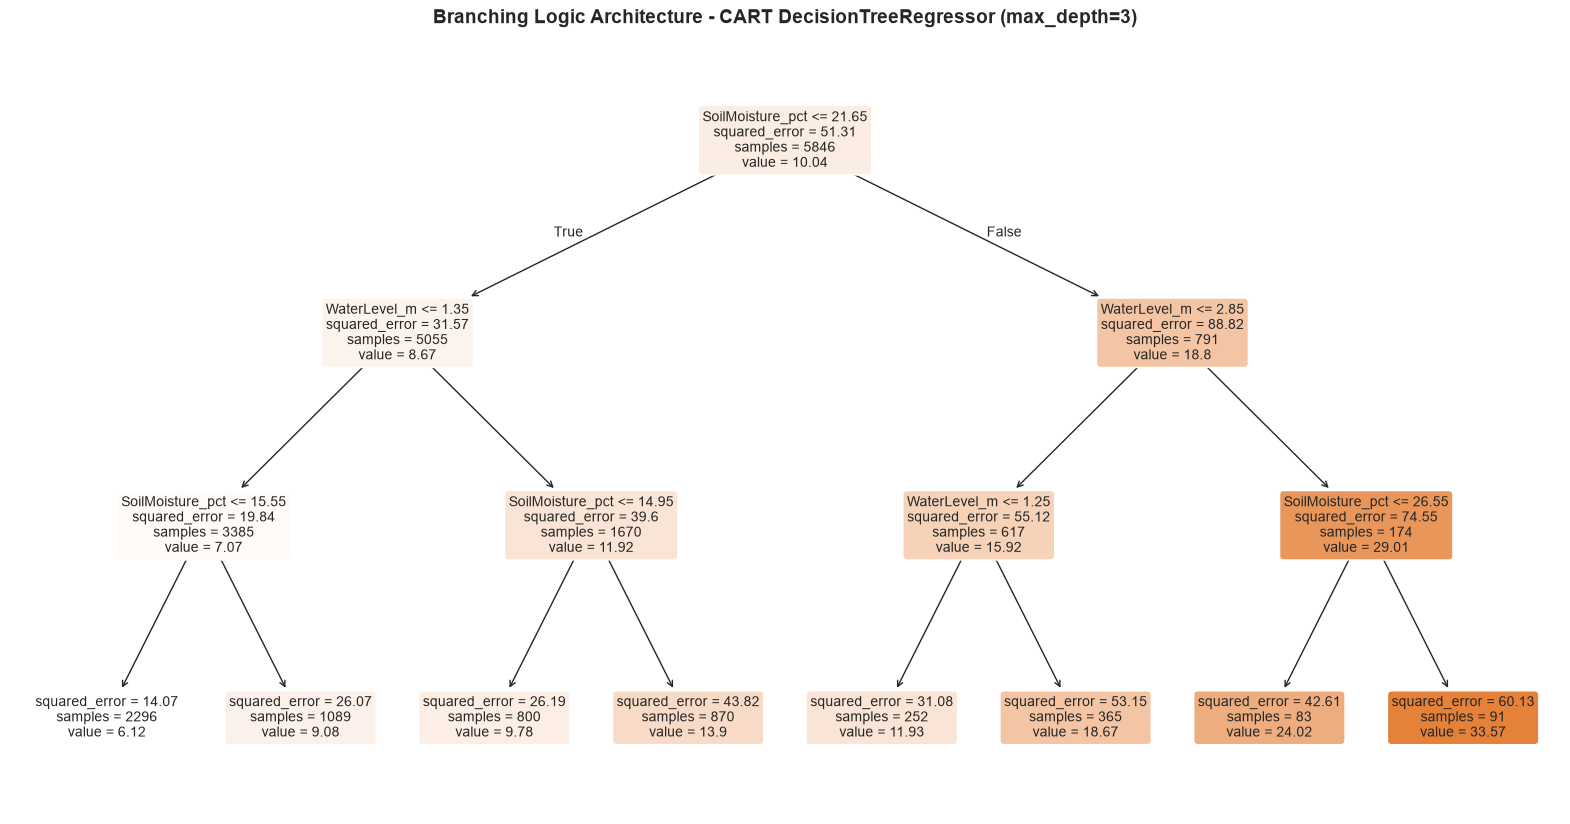

In [8]:
# ---DECISION TREE REGRESSOR DECISION LOGIC ARCHITECTURE VISUALIZATION---

plt.figure(figsize=(20, 10))
plot_tree(
    tree_reg_model,
    feature_names=cart_features,
    filled=True,
    rounded=True,
    precision=2,
    fontsize=10
)
plt.title("Branching Logic Architecture - CART DecisionTreeRegressor (max_depth=3)", 
          fontsize=14, fontweight='bold', pad=15)

tree_export_path = os.path.join(FIG_DIR, "cart_regressor_tree_diagram.png")
plt.savefig(tree_export_path, dpi=300, bbox_inches='tight')
print(f"Saved decision tree diagram to: {tree_export_path}")
plt.show()

Saved classifier feature importance plot to: figures\cart_classifier_feature_importance.png


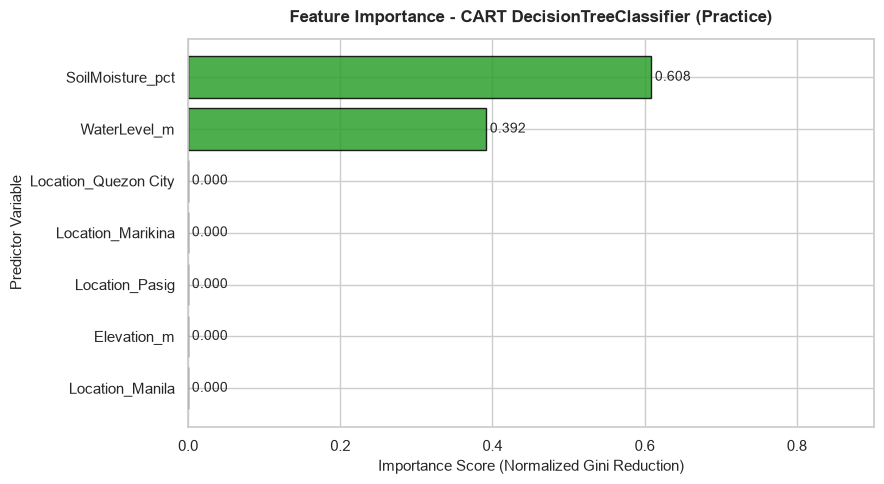


--- Classifier Feature Importance Ranking ---


,Feature,Importance
0,SoilMoisture_pct,0.783799
1,WaterLevel_m,0.216201
2,Location_Manila,0.000000
3,Location_Pasig,0.000000
4,Elevation_m,0.000000
5,Location_Quezon City,0.000000
6,Location_Marikina,0.000000


In [9]:
# ---FEATURE IMPORTANCE & EXPLAINABILITY - CLASSIFIER TREE---
# Metric: Mean Decrease in Impurity (Gini Impurity Reduction)

clf_importances = tree_clf_model.feature_importances_

clf_fi_df = pd.DataFrame({
    'Feature': cart_features,
    'Importance': clf_importances
}).sort_values(by='Importance', ascending=True)

# horizontal bar chart
plt.figure(figsize=(9, 5))
bars = plt.barh(fi_df['Feature'], fi_df['Importance'], color='#2ca02c', edgecolor='black', alpha=0.85)
plt.title("Feature Importance - CART DecisionTreeClassifier (Practice)", fontsize=12, fontweight='bold', pad=12)
plt.xlabel("Importance Score (Normalized Gini Reduction)", fontsize=11)
plt.ylabel("Predictor Variable", fontsize=11)

max_imp = max(clf_fi_df['Importance']) if len(clf_fi_df) > 0 else 0
plt.xlim(0, max_imp * 1.15 if max_imp > 0 else 1.0)

for bar in bars:
    width = bar.get_width()
    plt.text(
        width + 0.005, 
        bar.get_y() + bar.get_height() / 2, 
        f"{width:.3f}", 
        va='center', 
        ha='left', 
        fontsize=10, 
        fontweight='medium'
    )

plt.tight_layout()

# notebooks/figures/
clf_fi_path = os.path.join(FIG_DIR, "cart_classifier_feature_importance.png")
plt.savefig(clf_fi_path, dpi=300, bbox_inches='tight')
print(f"Saved classifier feature importance plot to: {clf_fi_path}")
plt.show()

# table
print("\n--- Classifier Feature Importance Ranking ---")
display(clf_fi_df.sort_values(by='Importance', ascending=False).reset_index(drop=True))

Saved classifier decision tree diagram to: figures\cart_classifier_tree_diagram.png


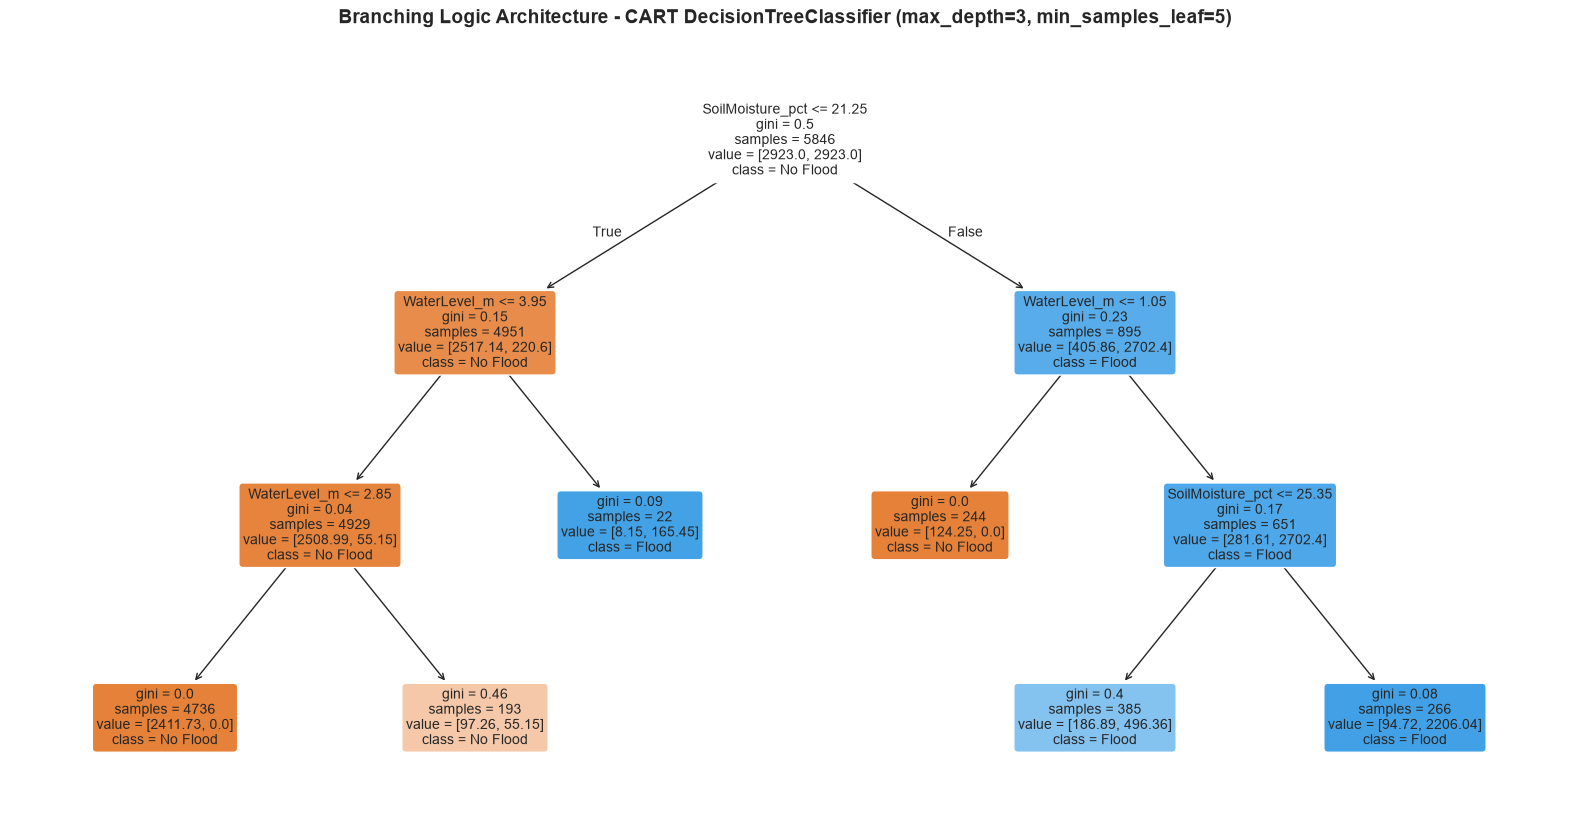

In [10]:
# ---DECISION TREE CLASSIFIER DECISION LOGIC ARCHITECTURE VISUALIZATION---

plt.figure(figsize=(20, 10))
plot_tree(
    tree_clf_model,
    feature_names=cart_features,
    class_names=["No Flood", "Flood"],
    filled=True,
    rounded=True,
    precision=2,
    fontsize=10
)
plt.title("Branching Logic Architecture - CART DecisionTreeClassifier (max_depth=3, min_samples_leaf=5)", 
          fontsize=14, fontweight='bold', pad=15)

clf_tree_path = os.path.join(FIG_DIR, "cart_classifier_tree_diagram.png")
plt.savefig(clf_tree_path, dpi=300, bbox_inches='tight')
print(f"Saved classifier decision tree diagram to: {clf_tree_path}")
plt.show()

## Step 3: Model Training & Evaluation Summary

### 1. Modeling Strategy & Intentional Feature Set Differences
- **Regression Task:** Predicting continuous `Rainfall_mm` (temporary placeholder for `FloodDepth_m`).
- **Linear Baseline (Multiple Linear Regression):** Trained on dynamic hydrometeorological features (`WaterLevel_m`, `SoilMoisture_pct`) and 3 city dummy variables (with Manila dropped as reference). `Elevation_m` was strictly excluded to prevent matrix singularity and coefficient distortion caused by perfect multicollinearity (established via VIF in EDA).
- **Primary CART Model (`DecisionTreeRegressor`, max_depth=3):** Evaluated with all predictors, including `Elevation_m` and all 4 city indicators. Tree algorithms split features independently along orthogonal axes, making them inherently robust to collinearity and capable of capturing non-linear regional thresholds.

### 2. Regression Performance Comparison
- **Multiple Linear Regression (Baseline):**
  - MAE: 3.8469 mm
  - RMSE: 4.9179 mm
  - R^2 Score: 0.4844
- **CART DecisionTreeRegressor (Primary Model):**
  - MAE: 4.0344 mm
  - RMSE: 5.2277 mm
  - R^2 Score: 0.4174
- **Key Observation:** On the temporary continuous target (`Rainfall_mm`), Multiple Linear Regression slightly outperformed the constrained CART regressor (`max_depth=3`, 8 terminal leaves) due to the smooth distribution of synthetic meteorological values. However, real hydrologic hazard data (`FloodDepth_m`) is governed by sharp physical thresholds (e.g., riverbank overtopping, drainage capacity limits). CART-based partitioning is expected to demonstrate superior performance once real flood depth targets are introduced in Phase 2.

### 3. Classification Pipeline Practice (Dry Run)
- Successfully tested classification pipelines using `FloodOccurrence` (binary target) across `LogisticRegression` and `DecisionTreeClassifier`.
- Verified that `class_weight='balanced'` properly prevents majority-class bias on imbalanced hazard data, ensuring high Recall on positive flood events.
- These results serve strictly as technical verification of our classification workflow; formal modeling will occur once MGB-derived multi-class `RiskLevel` is introduced.

### 4. Explainability & Thesis Visualizations
- Exported feature importance bar charts and branching tree diagrams to `notebooks/figures/`:
  - `figures/cart_regressor_feature_importance.png`
  - `figures/cart_regressor_tree_diagram.png`
  - `figures/cart_classifier_feature_importance.png`
  - `figures/cart_classifier_tree_diagram.png`